<a href="https://colab.research.google.com/github/mkg6573/Unsupervised_Machine_Learning/blob/main/kmeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

/tmp/ipykernel_17615/2941028727.py:10: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[:, 0], X[:, 1], s=50, cmap='viridis')


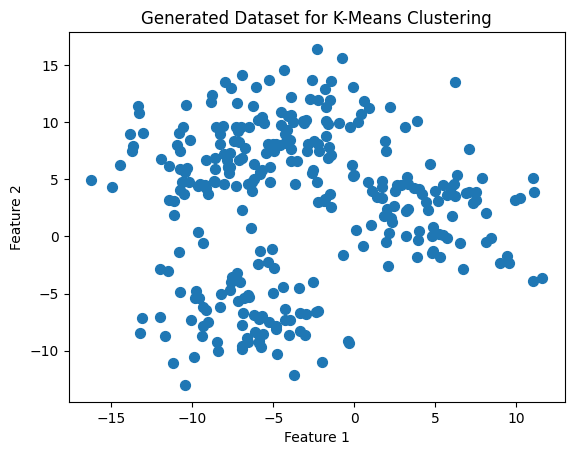

In [ ]:
# Parameters
n_samples = 300
n_features = 2
centers = 4

# Generate data
X, y = make_blobs(n_samples=n_samples, n_features=n_features, centers=centers, cluster_std=3, random_state=42)

# Visualize the data
plt.scatter(X[:, 0], X[:, 1], s=50, cmap='viridis')
plt.title("Generated Dataset for K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [ ]:
from sklearn.cluster import KMeans

wcss = []
for i in range(1,11):
  kmeans = KMeans(n_init = 10,n_clusters=i)
  kmeans.fit(X)
  wcss.append(kmeans.inertia_)

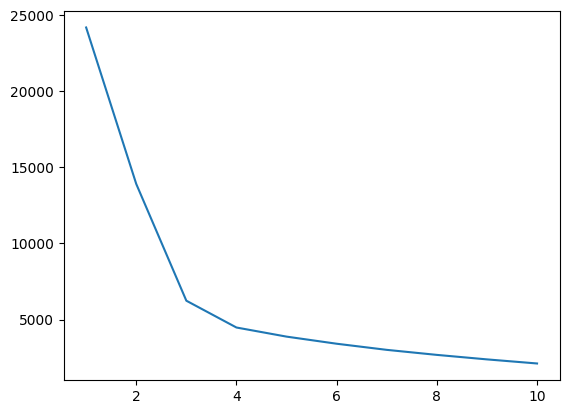

In [ ]:
plt.plot(range(1,11),wcss)

In [ ]:
from sklearn.metrics import silhouette_score
sil = []
for i in range(2,11):
  kmeans = KMeans(n_clusters=i)
  cluster_labels = kmeans.fit_predict(X)
  silhouette_avg = silhouette_score(X,cluster_labels)
  sil.append(silhouette_avg)

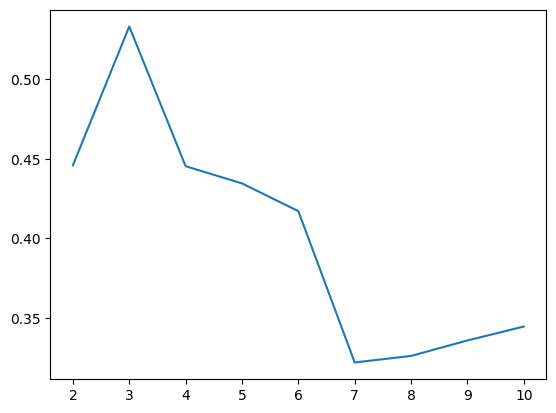

In [ ]:
plt.plot(range(2,11),sil)

In [ ]:
kmeans = KMeans(n_init = 10,n_clusters=4,verbose=100)
kmeans.fit(X)

Initialization complete
Iteration 0, inertia 9708.647966354829.
Iteration 1, inertia 6017.144599599901.
Iteration 2, inertia 5701.738646493998.
Iteration 3, inertia 5474.273703599954.
Iteration 4, inertia 5052.855216473388.
Iteration 5, inertia 4585.739417754978.
Iteration 6, inertia 4525.199921151416.
Iteration 7, inertia 4486.970627392466.
Iteration 8, inertia 4485.746472115658.
Iteration 9, inertia 4483.070290877198.
Iteration 10, inertia 4477.333098866025.
Iteration 11, inertia 4475.918395021896.
Converged at iteration 11: strict convergence.
Initialization complete
Iteration 0, inertia 5833.1726110610825.
Iteration 1, inertia 4672.034928961005.
Iteration 2, inertia 4545.91389617158.
Iteration 3, inertia 4495.542087264771.
Iteration 4, inertia 4485.746472115658.
Iteration 5, inertia 4483.070290877198.
Iteration 6, inertia 4477.333098866025.
Iteration 7, inertia 4475.918395021896.
Converged at iteration 7: strict convergence.
Initialization complete
Iteration 0, inertia 10450.492025

KMeans(n_clusters=4, n_init=10, verbose=100)

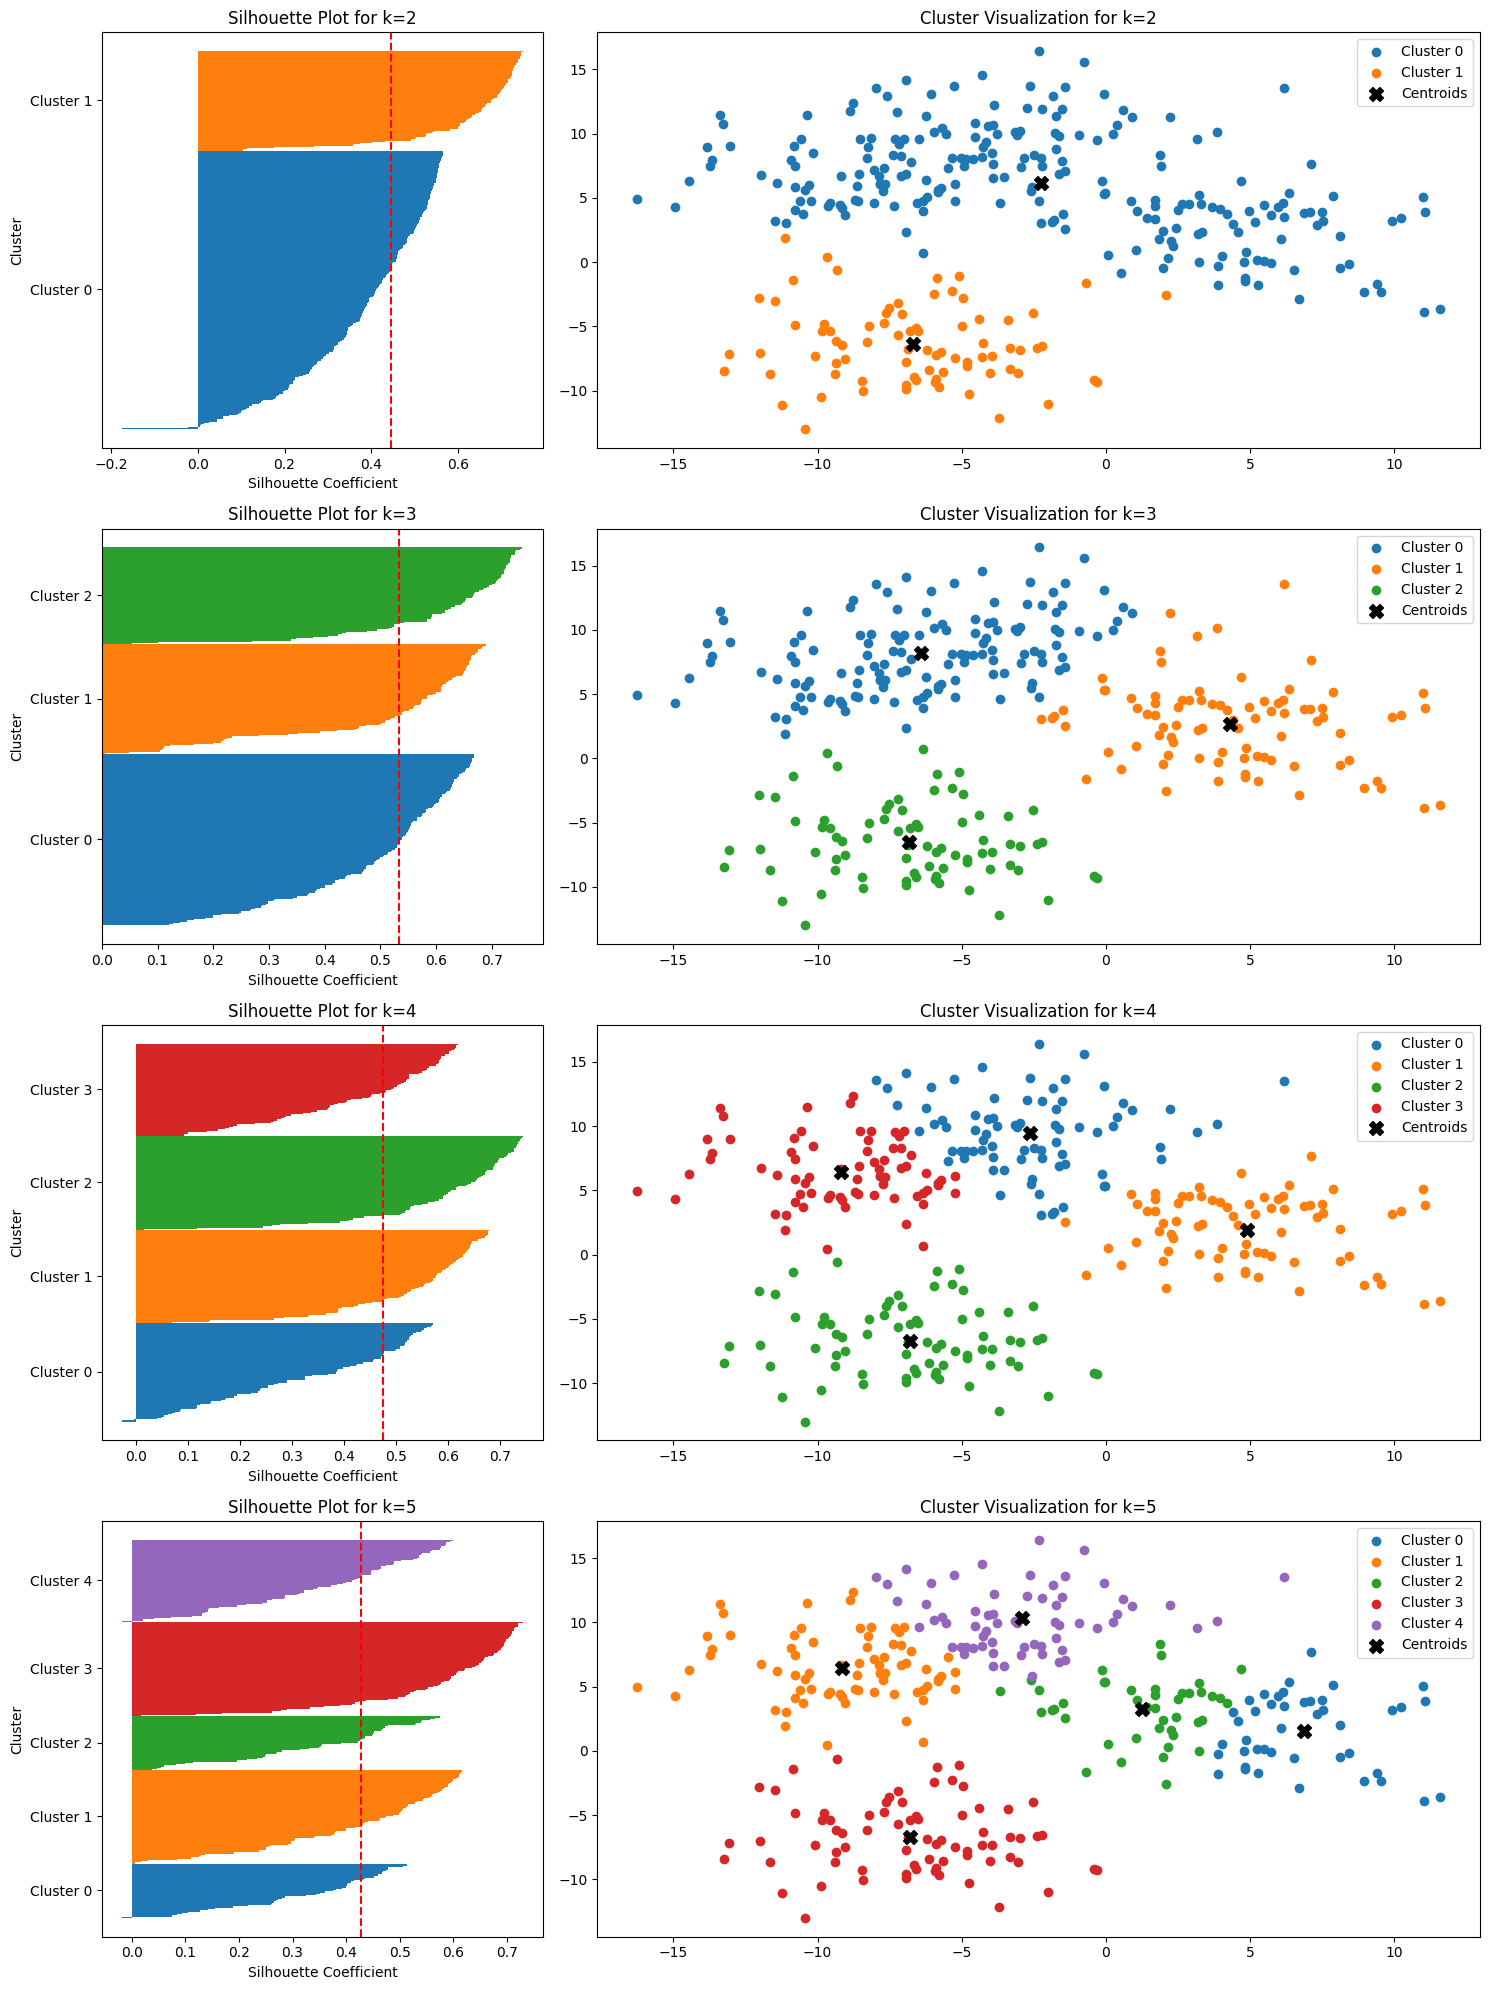

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.datasets import make_blobs

from sklearn.metrics import silhouette_samples, silhouette_score
import numpy as np


# Setting up the subplot grid
fig = plt.figure(figsize=(15, 20))
gs = gridspec.GridSpec(4, 2, width_ratios=[1, 2])

# Creating silhouette and scatter plots for different values of k (2, 3, 4, 5)
for i, k in enumerate([2, 3, 4, 5]):
    # Clustering with k-means
    kmeans = KMeans(n_init=10, n_clusters=k, random_state=10)
    cluster_labels = kmeans.fit_predict(X)

    # Silhouette values
    silhouette_vals = silhouette_samples(X, cluster_labels)
    avg_score = silhouette_score(X, cluster_labels)

    # Silhouette plot
    ax1 = plt.subplot(gs[i, 0])
    y_lower, y_upper = 0, 0
    yticks = []
    for j, cluster in enumerate(np.unique(cluster_labels)):
        cluster_silhouette_vals = silhouette_vals[cluster_labels == cluster]
        cluster_silhouette_vals.sort()
        y_upper += len(cluster_silhouette_vals)
        ax1.barh(range(y_lower, y_upper), cluster_silhouette_vals, edgecolor='none', height=1)
        yticks.append((y_lower + y_upper) / 2)
        y_lower += len(cluster_silhouette_vals)
    ax1.axvline(avg_score, color="red", linestyle="--")
    ax1.set_yticks(yticks)
    ax1.set_yticklabels([f'Cluster {x}' for x in np.unique(cluster_labels)])
    ax1.set_ylabel('Cluster')
    ax1.set_xlabel('Silhouette Coefficient')
    ax1.set_title(f'Silhouette Plot for k={k}')

    # Scatter plot
    ax2 = plt.subplot(gs[i, 1])
    for j in np.unique(cluster_labels):
        ax2.scatter(X[cluster_labels == j, 0], X[cluster_labels == j, 1], label=f'Cluster {j}')
    ax2.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=100, c='black', marker='X', label='Centroids')
    ax2.set_title(f'Cluster Visualization for k={k}')
    ax2.legend()

plt.tight_layout()
plt.show()


In [ ]:
y_kmeans = kmeans.fit_predict(X)

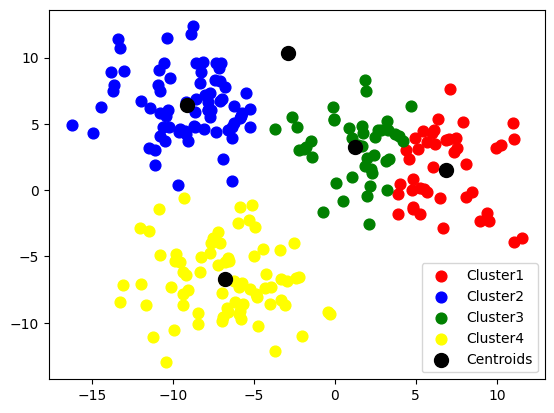

In [ ]:
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s = 60, c = 'red', label = 'Cluster1')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s = 60, c = 'blue', label = 'Cluster2')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s = 60, c = 'green', label = 'Cluster3')
plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], s = 60, c = 'yellow', label = 'Cluster4')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s = 100, c = 'black', label = 'Centroids')

plt.legend()

plt.show()